In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ===== Config =====
import os
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/nehamariamjose/cusat-summer-internship-ml/main/data/temp_vanilla.csv"
DATA_PATH = "temp_vanilla.csv"

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

#Load Data
df = pd.read_csv(DATA_PATH)

X = df[[
    "temp_morning",
    "temp_afternoon",
    "temp_evening"
]].values

y = df["next_day_temp"].values.reshape(-1,1)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(y_train.shape)


(80, 3)
(80, 1)


In [2]:
# =====================================================
# STANDARD SCALING
# =====================================================

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# =====================================================
# RNN PARAMETERS
# =====================================================

input_size = 1 # d=1
hidden_size = 8 # h =8
output_size = 1 # k=1
T=3

learning_rate = 0.001
epochs = 1000
# =====================================================
# WEIGHTS
# =====================================================

np.random.seed(42)

Wxh = np.random.randn(hidden_size,input_size)*0.1
Whh = np.random.randn(hidden_size,hidden_size)*0.1

bh = np.zeros((hidden_size,1))

Why = np.random.randn(output_size,hidden_size)*0.1
by = np.zeros((output_size,1))

# =====================================================


Epoch    0  Loss = 0.528006
Epoch  100  Loss = 0.045578
Epoch  200  Loss = 0.045460
Epoch  300  Loss = 0.045376
Epoch  400  Loss = 0.045313
Epoch  500  Loss = 0.045266
Epoch  600  Loss = 0.045228
Epoch  700  Loss = 0.045197
Epoch  800  Loss = 0.045169
Epoch  900  Loss = 0.045143
MSE : 2.6384
MAE : 1.3939


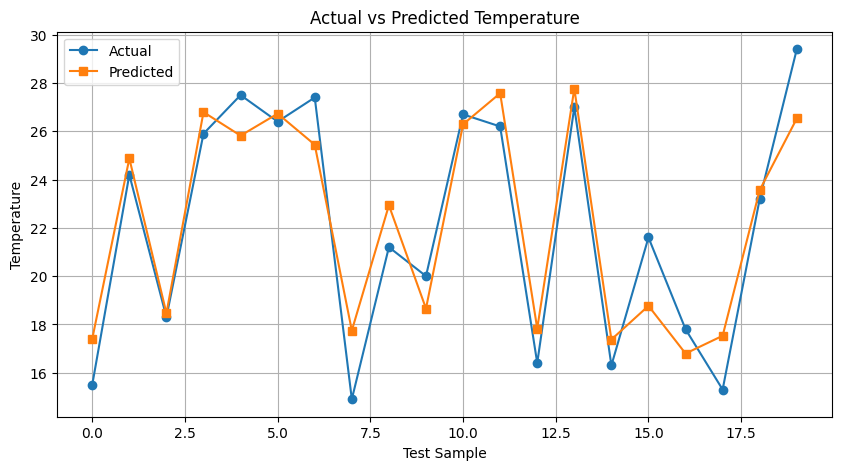

In [3]:
# =====================================================
# TRAINING
# =====================================================

loss_history = []

for epoch in range(epochs):

    total_loss = 0

    for n in range(len(X_train)):

        # ==========================================
        # INITIAL HIDDEN STATE
        # ==========================================

        h_prev = np.zeros((hidden_size,1))

        xs = []
        hs = []

        # ==========================================
        # FORWARD PASS
        # ==========================================

        for t in range(T):

            x_t = np.array([[X_train[n,t]]])

            h_prev = np.tanh(
                Wxh @ x_t +
                Whh @ h_prev +
                bh
            )

            xs.append(x_t)
            hs.append(h_prev)

        y_hat = Why @ hs[T-1] + by

        target = np.array([[y_train[n,0]]])

        loss = 0.5*np.sum((y_hat-target)**2)

        total_loss += loss

        # ==========================================
        # OUTPUT LAYER GRADIENT
        # ==========================================

        dy = y_hat - target

        dWhy = dy @ hs[T-1].T
        dby = dy

        # ==========================================
        # BPTT
        # ==========================================

        dWxh = np.zeros_like(Wxh)
        dWhh = np.zeros_like(Whh)
        dbh = np.zeros_like(bh)

        dh_next = Why.T @ dy # dh_T

        for t in reversed(range(3)): #t=2,1,0

            h = hs[t]

            dh = dh_next

            da = dh * (1 - h**2)

            dbh += da

            dWxh += da @ xs[t].T

            if t > 0:
                dWhh += da @ hs[t-1].T

            dh_next = Whh.T @ da

        # ==========================================
        # WEIGHT UPDATE
        # ==========================================

        Wxh -= learning_rate*dWxh
        Whh -= learning_rate*dWhh
        bh  -= learning_rate*dbh

        Why -= learning_rate*dWhy
        by  -= learning_rate*dby

    loss_history.append(total_loss)

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d}  Loss = {total_loss/len(X_train):.6f}"
        )

# =====================================================
# TESTING
# =====================================================

predictions = []

for n in range(len(X_test)):

    h_prev = np.zeros((hidden_size,1))

    for t in range(3):

        x_t = np.array([[X_test[n,t]]])

        h_prev = np.tanh(
            Wxh @ x_t +
            Whh @ h_prev +
            bh
        )

    y_hat = Why @ h_prev + by

    predictions.append(y_hat[0,0])

predictions = np.array(predictions).reshape(-1,1)

# =====================================================
# INVERSE TRANSFORM
# =====================================================

predictions = y_scaler.inverse_transform(predictions)

actual = y_test
# =====================================================
# EVALUATION
# =====================================================

mse = mean_squared_error(actual,predictions)
print(f"MSE : {mse:.4f}")

mae = mean_absolute_error(actual,predictions)
print(f"MAE : {mae:.4f}")

# ==========================================
# ACTUAL VS PREDICTED PLOT
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    actual,
    label="Actual",
    marker='o'
)

plt.plot(
    predictions,
    label="Predicted",
    marker='s'
)

plt.xlabel("Test Sample")
plt.ylabel("Temperature")

plt.title("Actual vs Predicted Temperature")

plt.legend()

plt.grid(True)

plt.show()

(80, 3)
(80, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch    0  Loss = 0.256296
Epoch  100  Loss = 0.043655
Epoch  200  Loss = 0.043289
Epoch  300  Loss = 0.042990
Epoch  400  Loss = 0.042737
Epoch  500  Loss = 0.042520
Epoch  600  Loss = 0.042333
Epoch  700  Loss = 0.042173
Epoch  800  Loss = 0.042036
Epoch  900  Loss = 0.041920
MSE : 2.6221
MAE : 1.3666


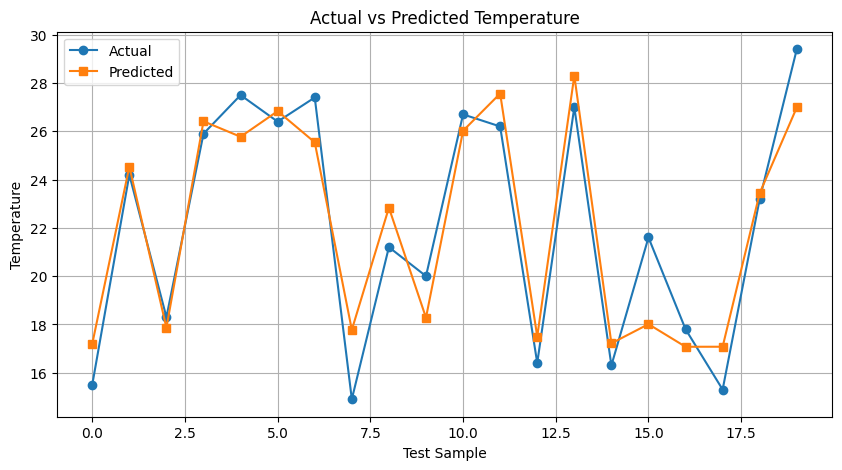

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv(DATA_PATH)

X = df[[
    "temp_morning",
    "temp_afternoon",
    "temp_evening"
]].values

y = df["next_day_temp"].values.reshape(-1, 1)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(y_train.shape)

# =====================================================
# STANDARD SCALING
# =====================================================

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# RNN expects shape (samples, timesteps, features)
X_train_seq = X_train.reshape(-1, 3, 1)
X_test_seq = X_test.reshape(-1, 3, 1)

# =====================================================
# RNN PARAMETERS
# =====================================================

hidden_size = 8     # h = 8
T = 3

learning_rate = 0.001
epochs = 1000

# =====================================================
# MODEL  (Wxh, Whh, bh, Why, by are created internally
# by SimpleRNN + Dense, matching the manual version)
# =====================================================

tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(
        hidden_size,
        activation="tanh",
        input_shape=(T, 1)
    ),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

# loss = 0.5 * sum of squared error, to match the manual code exactly
def half_sse(y_true, y_pred):
    return 0.5 * tf.reduce_sum(tf.square(y_true - y_pred))

model.compile(optimizer=optimizer, loss=half_sse)

# =====================================================
# TRAINING
# (batch_size=1 = update weights after every sample,
# same as the manual per-sample loop)
# =====================================================

history = model.fit(
    X_train_seq,
    y_train,
    epochs=epochs,
    batch_size=1,
    verbose=0
)

for epoch in range(0, epochs, 100):
    print(f"Epoch {epoch:4d}  Loss = {history.history['loss'][epoch]:.6f}")

# =====================================================
# TESTING
# =====================================================

predictions_scaled = model.predict(X_test_seq, verbose=0)

# =====================================================
# INVERSE TRANSFORM
# =====================================================

predictions = y_scaler.inverse_transform(predictions_scaled)

actual = y_test

# =====================================================
# EVALUATION
# =====================================================

mse = mean_squared_error(actual, predictions)
print(f"MSE : {mse:.4f}")

mae = mean_absolute_error(actual, predictions)
print(f"MAE : {mae:.4f}")

# =====================================================
# ACTUAL VS PREDICTED PLOT
# =====================================================

plt.figure(figsize=(10, 5))
plt.plot(actual, label="Actual", marker='o')
plt.plot(predictions, label="Predicted", marker='s')
plt.xlabel("Test Sample")
plt.ylabel("Temperature")
plt.title("Actual vs Predicted Temperature")
plt.legend()
plt.grid(True)
plt.show()